# Experimenting DiffRec on Gowalla and Tmall

This notebook is used for inspecting the based DiffRec implementation on un-tested datasets. The experiment for each dataset includes two stages:
+ Training: Run the training command provided by the author to train the model.
+ Inference: Use the trained model on validation and test sets to obtain the evaluation metrics's results.

The metrics used for evaluation are __Recall@N__ and __Normalized Discounted Cumulative Gain (NDCG)@N__, with N   {20, 40}.

Before using this notebook, please ensure all necessary packages are installed. The list of packages can be found inside the `requirements.txt`.

In [1]:
import os
from argparse import Namespace

In [2]:
os.environ["USE_TQDM_NOTEBOOK"] = "1"

In [3]:
from main import train_model
from inference import infer_model

## 1. Training

This section contains code for training DiffRec on Gowalla and Tmall datasets with configurable arguments:

### 1.1 Training on Gowalla 

In [ ]:
if __name__ == "__main__":
    # Make a Namespace class containing arguments for training
    args = Namespace(
        cuda = True, # Un-check this if there is no CUDA-supported device
        topN = "[20]", # Use Recall@20 only for validation
        dataset = "gowalla", 
        tst_w_val = True, # Use validation with training to predict test
        lr = 1e-4, # Learning rate
        weight_decay = 1e-5, # Model control coefficient
        batch_size = 512, # Batch size when training
        infer_batch_size = 1024, # Batch size when validating, utilize GPU more efficient
        epochs = 500,
        dims = "[1000, 1000]", # Underlying Denoising MLP model
        emb_size = 12, # Timestep-embedding, necessary for Diffusion model
        steps = 60, # Denoising steps
        noise_scale = 0.125, 
        noise_min = 1e-5,
        noise_max = 0.02,
        sampling_steps = 0, # No sampling in inference
        loss_logging = False # Turn off epoch loss/cost results, for a clean log
    )
    train_model(args)

args: Namespace(dataset='gowalla', data_path='./datasets/', lr=0.0001, weight_decay=1e-05, batch_size=512, infer_batch_size=1024, epochs=500, topN='[20]', tst_w_val=True, cuda=True, gpu='0', save_path='./saved_models/', log_name='log', round=1, loss_logging=False, time_type='cat', dims='[1000, 1000]', norm=False, emb_size=12, mean_type='x0', steps=60, noise_schedule='linear-var', noise_scale=0.125, noise_min=1e-05, noise_max=0.02, sampling_noise=False, sampling_steps=0, reweight=True)
Starting time:  2026-04-01 23:23:20
user num: 50821
item num: 57440
data ready.
models ready.
Number of all parameters: 116952596
Start training...


Training:   0%|          | 0/500 [00:00<?, ?it/s]

Batches:   0%|          | 0/100 [00:00<?, ?it/s]

Batches:   0%|          | 0/100 [00:00<?, ?it/s]

Batches:   0%|          | 0/100 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/100 [00:00<?, ?it/s]

Batches:   0%|          | 0/100 [00:00<?, ?it/s]

Batches:   0%|          | 0/100 [00:00<?, ?it/s]

Batches:   0%|          | 0/100 [00:00<?, ?it/s]

------------------
Exiting from training early
End. Best Epoch 055 
[Valid]: Precision: 0.0162 Recall: 0.1665 NDCG: 0.091 MRR: 0.0926
[Test]: Precision: 0.0193 Recall: 0.1271 NDCG: 0.0808 MRR: 0.1078
End time:  2026-04-02 00:43:22
Best model saved to  ./saved_models/gowalla_lr0.0001_wd1e-05_bs512_ibs1024_dims[1000, 1000]_emb12_x0_steps60_scale0.125_min1e-05_max0.02_sample0_reweightTrue_log.pth


### 1.2 Training on Tmall

In [5]:
if __name__ == "__main__":
    # Make a Namespace class containing arguments for training
    args = Namespace(
        cuda = True, # Un-check this if there is no CUDA-supported device
        topN = "[20]", # Use Recall@20 only for validation
        dataset = "tmall", 
        tst_w_val = True, # Use validation with training to predict test
        lr = 1e-4, # Learning rate
        weight_decay = 1e-5, # Model control coefficient
        batch_size = 512, # Batch size when training
        infer_batch_size = 1024, # Batch size when validating, utilize GPU more efficient
        epochs = 500,
        dims = "[1000, 1000]", # Underlying Denoising MLP model
        emb_size = 12, # Timestep-embedding, necessary for Diffusion model
        steps = 60, # Denoising steps
        noise_scale = 0.125, 
        noise_min = 1e-5,
        noise_max = 0.015, # Slightly lower noise upper-bound for Tmall
        sampling_steps = 0, # No sampling in inference
        loss_logging = False # Turn off epoch loss/cost results, for a clean log
    )
    train_model(args)

args: Namespace(dataset='tmall', data_path='./datasets/', lr=0.0001, weight_decay=1e-05, batch_size=512, infer_batch_size=1024, epochs=500, topN='[20]', tst_w_val=True, cuda=True, gpu='0', save_path='./saved_models/', log_name='log', round=1, loss_logging=False, time_type='cat', dims='[1000, 1000]', norm=False, emb_size=12, mean_type='x0', steps=60, noise_schedule='linear-var', noise_scale=0.125, noise_min=1e-05, noise_max=0.015, sampling_noise=False, sampling_steps=0, reweight=True)
Starting time:  2026-04-02 00:43:22
user num: 47939
item num: 41390
data ready.
models ready.
Number of all parameters: 84836546
Start training...


Training:   0%|          | 0/500 [00:00<?, ?it/s]

Batches:   0%|          | 0/94 [00:00<?, ?it/s]

Batches:   0%|          | 0/94 [00:00<?, ?it/s]

Batches:   0%|          | 0/94 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/94 [00:00<?, ?it/s]

Batches:   0%|          | 0/94 [00:00<?, ?it/s]

Batches:   0%|          | 0/94 [00:00<?, ?it/s]

Batches:   0%|          | 0/94 [00:00<?, ?it/s]

------------------
Exiting from training early
End. Best Epoch 095 
[Valid]: Precision: 0.0181 Recall: 0.0814 NDCG: 0.0554 MRR: 0.0887
[Test]: Precision: 0.0227 Recall: 0.0823 NDCG: 0.0602 MRR: 0.1096
End time:  2026-04-02 02:17:38
Best model saved to  ./saved_models/tmall_lr0.0001_wd1e-05_bs512_ibs1024_dims[1000, 1000]_emb12_x0_steps60_scale0.125_min1e-05_max0.015_sample0_reweightTrue_log.pth


# 2. Inference

This section contains code to perform inference on trained models from the section above (1.), with configurable arguments. 

If you have adjust the training configuration above, please wait for the training to be completed and re-new the path to the trained model in the argument `model_name` (also the `model_path` if needed).

In [10]:
topN = "[20, 40]"

### 2.1 Inference on Gowalla

In [ ]:
if __name__ == "__main__":
    # Make a Namespace class containing arguments for inference
    args = Namespace(
        cuda = True,
        dataset = "gowalla",
        model_path = "./saved_models/",
        model_name = "gowalla_lr0.0001_wd1e-05_bs512_ibs1024_dims[1000, 1000]_emb12_x0_steps60_scale0.125_min1e-05_max0.02_sample0_reweightTrue_log.pth",
        tst_w_val = True,
        batch_size = 1024,
        topN = topN,
        steps = 60,
        noise_scale = 0.125, 
        noise_min = 1e-5,
        noise_max = 0.02,
        sampling_steps=0
    )

    gowalla_results = infer_model(args)

args: Namespace(dataset='gowalla', data_path='./datasets/', batch_size=1024, topN='[20, 40]', tst_w_val=True, cuda=True, gpu='0', log_name='log', mean_type='x0', steps=60, noise_schedule='linear-var', noise_scale=0.125, noise_min=1e-05, noise_max=0.02, sampling_noise=False, sampling_steps=0, model_path='./saved_models/', model_name='gowalla_lr0.0001_wd1e-05_bs512_ibs1024_dims[1000, 1000]_emb12_x0_steps60_scale0.125_min1e-05_max0.02_sample0_reweightTrue_log.pth')
Starting time:  2026-04-02 12:02:37
user num: 50821
item num: 57440
data ready.
models ready.


Inference:   0%|          | 0/50 [00:00<?, ?it/s]

Inference:   0%|          | 0/50 [00:00<?, ?it/s]

[Valid]: Precision: 0.0162-0.0113 Recall: 0.1665-0.2283 NDCG: 0.091-0.1055 MRR: 0.0926-0.0953
[Test]: Precision: 0.0193-0.0135 Recall: 0.1271-0.1752 NDCG: 0.0808-0.0936 MRR: 0.1078-0.1103


### 2.2 Inference on Tmall

In [ ]:
if __name__ == "__main__":
    # Make a Namespace class containing arguments for inference
    args = Namespace(
        cuda = True,
        dataset = "tmall",
        model_path = "./saved_models/",
        model_name = "tmall_lr0.0001_wd1e-05_bs512_ibs1024_dims[1000, 1000]_emb12_x0_steps60_scale0.125_min1e-05_max0.015_sample0_reweightTrue_log.pth",
        tst_w_val = True,
        batch_size = 1024,
        topN = topN,
        steps = 60,
        noise_scale = 0.125, 
        noise_min = 1e-5,
        noise_max = 0.015,
        sampling_steps=0
    )

    tmall_results = infer_model(args)

args: Namespace(dataset='tmall', data_path='./datasets/', batch_size=1024, topN='[20, 40]', tst_w_val=True, cuda=True, gpu='0', log_name='log', mean_type='x0', steps=60, noise_schedule='linear-var', noise_scale=0.125, noise_min=1e-05, noise_max=0.015, sampling_noise=False, sampling_steps=0, model_path='./saved_models/', model_name='tmall_lr0.0001_wd1e-05_bs512_ibs1024_dims[1000, 1000]_emb12_x0_steps60_scale0.125_min1e-05_max0.015_sample0_reweightTrue_log.pth')
Starting time:  2026-04-02 12:06:32
user num: 47939
item num: 41390
data ready.
models ready.


Inference:   0%|          | 0/47 [00:00<?, ?it/s]

Inference:   0%|          | 0/47 [00:00<?, ?it/s]

[Valid]: Precision: 0.0181-0.0138 Recall: 0.0814-0.1235 NDCG: 0.0554-0.0692 MRR: 0.0887-0.0928
[Test]: Precision: 0.0227-0.0171 Recall: 0.0823-0.1244 NDCG: 0.0602-0.0749 MRR: 0.1096-0.1138


# 3. Illustration

In [82]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [58]:
def extract_test_metrics(results):
    N_value = eval(topN)
    
    metrics = {}
    metrics_name = ["Recall@", "NDCG@"]
    
    test_results = results[1]

    for i, n in enumerate(N_value):
        for j, name in enumerate(metrics_name):
            metrics[f'{name}{n}'] = test_results[1+j][i]

    return metrics

gowalla_metrics = extract_test_metrics(gowalla_results)
tmall_metrics = extract_test_metrics(tmall_results)

In [59]:
gowalla_metrics

{'Recall@20': 0.1271,
 'NDCG@20': 0.0808,
 'Recall@40': 0.1752,
 'NDCG@40': 0.0936}

In [60]:
tmall_metrics

{'Recall@20': 0.0823,
 'NDCG@20': 0.0602,
 'Recall@40': 0.1244,
 'NDCG@40': 0.0749}

In [76]:
df_gowalla = pd.DataFrame(index=['LightGCN', 'SimGCL', 'LightGCL', 'DiffRec'], columns=gowalla_metrics.keys())

df_gowalla.loc['LightGCN'] = "0.0985 0.0593 0.1431 0.0710".split(" ")
df_gowalla.loc['SimGCL']   = "0.1357 0.0818 0.1956 0.0975".split(" ")
df_gowalla.loc['LightGCL'] = "0.1578 0.0935 0.2245 0.1108".split(" ")
df_gowalla = df_gowalla.astype(float)

df_gowalla.loc['DiffRec']  = gowalla_metrics
df_gowalla

,Recall@20,NDCG@20,Recall@40,NDCG@40
LightGCN,0.0985,0.0593,0.1431,0.0710
SimGCL,0.1357,0.0818,0.1956,0.0975
LightGCL,0.1578,0.0935,0.2245,0.1108
DiffRec,0.1271,0.0808,0.1752,0.0936


In [77]:
df_tmall = pd.DataFrame(index=['LightGCN', 'SimGCL', 'LightGCL', 'DiffRec'], columns=tmall_metrics.keys())

df_tmall.loc['LightGCN'] = "0.0225 0.0154 0.0378 0.0208".split(" ")
df_tmall.loc['SimGCL']   = "0.0473 0.0328 0.0766 0.0429".split(" ")
df_tmall.loc['LightGCL'] = "0.0528 0.0361 0.0852 0.0473".split(" ")
df_tmall = df_tmall.astype(float)

df_tmall.loc['DiffRec']  = tmall_metrics
df_tmall

,Recall@20,NDCG@20,Recall@40,NDCG@40
LightGCN,0.0225,0.0154,0.0378,0.0208
SimGCL,0.0473,0.0328,0.0766,0.0429
LightGCL,0.0528,0.0361,0.0852,0.0473
DiffRec,0.0823,0.0602,0.1244,0.0749


In [141]:
def plot_dataset(df: pd.DataFrame):
    metrics = ['Recall@', 'NDCG@']
    
    models = df.index
    x = np.arange(len(models))

    N_values = eval(topN)
    width = 0.6 / len(N_values)
    fig, axs = plt.subplots(nrows=len(metrics), figsize=(6, 4 * len(metrics)))

    for i, metric_name in enumerate(metrics):
        for j, n in enumerate(N_values):
            offset = (j - (len(N_values) - 1) / 2) * width
            axs[i].bar(x + offset, df[f'{metric_name}{n}'], width, label=f'{metric_name}{n}')
        
        axs[i].set_xticks(x)
        axs[i].set_xticklabels(models, rotation=20)

        axs[i].set_ylabel(metric_name)
        axs[i].legend()

    
    plt.tight_layout()
    plt.show()

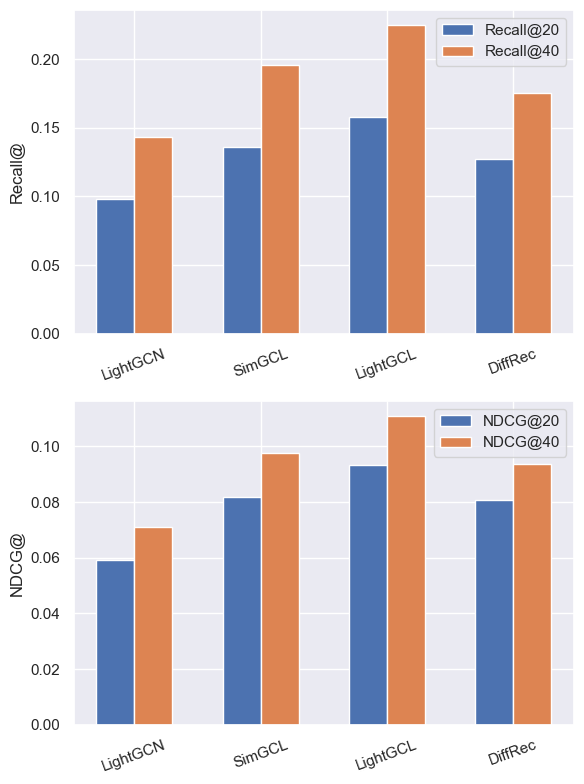

In [142]:
plot_dataset(df_gowalla)

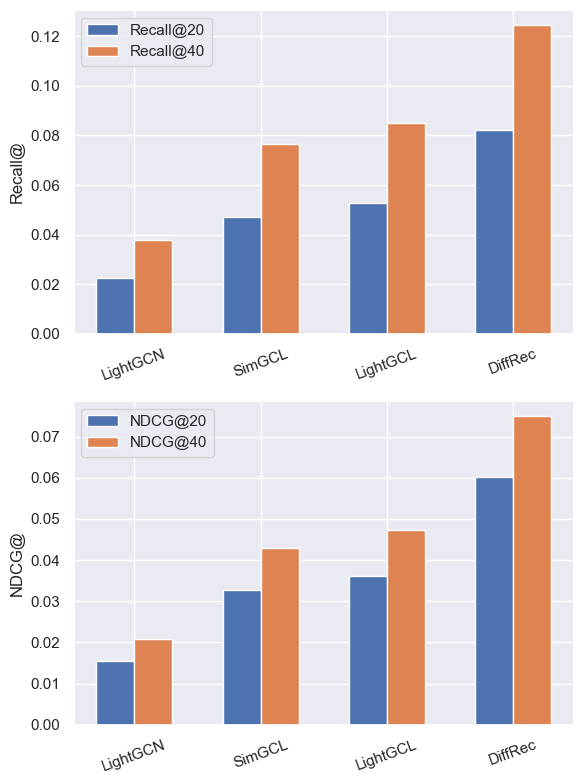

In [143]:
plot_dataset(df_tmall)